In [30]:
import os
import time
import random
import cv2

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras import models, Sequential, layers
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    CSVLogger,
    ReduceLROnPlateau
)

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.vision import drawing_utils
from mediapipe.tasks.python.vision import drawing_styles

from tensorflow.keras.optimizers import AdamW
import keras_tuner as kt

In [2]:
import torch
torch.cuda.is_available()

True

### FACE LANDMARKER

In [3]:
'''
base_oprtions - is to specify model path
options - is to specify:
 - output_face_blendshapes (True to get blendshapes)
 - output_facial_transformation_matrixes(True to get transformation matrixes)
 - num_faces(1 to detect one face)
detector - is to create face landmarker object to detect face landmarks
'''
base_options = python.BaseOptions(model_asset_path='../face_landmarker_v2_with_blendshapes.task')
options = vision.FaceLandmarkerOptions(base_options=base_options,
                                       output_face_blendshapes=True,
                                       output_facial_transformation_matrixes=True,
                                       num_faces=1)
detector = vision.FaceLandmarker.create_from_options(options)


TRAIN_DATA_PATH = "../affectnet_dataset/Train"
TEST_DATA_PATH = "../affectnet_dataset/Test"
ORIGINAL_DATA_PATH = "../affectnet_dataset"
# CLAHE_DATASET_PATH = "../clahe_dataset"
# MASK_DATASET_PATH = "../mask_dataset"

EPOCHS = 100
RANDOM_SEED = 40
BATCH_SIZE = 32
IMG_SIZE = (96,96)
SAVED_MODEL = "../saved_models/mlp_kt_model.h5"

In [4]:
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
tf.keras.utils.set_random_seed(RANDOM_SEED)

In [5]:
keypoints_dir = "../affectnet_keypoints"

os.makedirs(keypoints_dir, exist_ok=True)

data_dirs = {
    "train": TRAIN_DATA_PATH,
    "test": TEST_DATA_PATH
}

In [6]:
folder = "../affectnet_keypoints/train/contempt"

# List all .npy files to check if keypoints are saved correctly
files = [f for f in os.listdir(folder) if f.endswith(".npy")]

first_img = os.path.join(folder, files[0])
keypoints = np.load(first_img)
print(keypoints.shape)

(478, 3)


In [7]:
# Load keypoints array and labels from the dataset
def load_keypoints_dataset(base_dir):
    X, y = [], []
    for class_name in sorted(os.listdir(base_dir)):
        class_path = os.path.join(base_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        for file in os.listdir(class_path):
            if not file.endswith(".npy"):
                continue
            keypoints = np.load(os.path.join(class_path, file))
            X.append(keypoints)
            y.append(class_name)
    return np.array(X), np.array(y)

X, y = load_keypoints_dataset("../affectnet_keypoints/train")

In [8]:
print(y[:5])

['anger' 'anger' 'anger' 'anger' 'anger']


In [9]:
'''
LabelEncoder() - to convert string lbl to int
to_categorical() - to convert int lbl to one-hot encoding
reshape - to convert 3D array (samples, landmarks, coordinates) 
to 2D array (samples, features), because MLP expects 2D input (samples, features)

StandardScaler() - to standardize features by removing the mean and scaling to unit variance
(data is scaled to have a standard deviation of 1)
'''
le = LabelEncoder()
y = le.fit_transform(y)
# y = to_categorical(y)

# Split FIRST
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = X_train.reshape(X_train.shape[0], -1)
X_val   = X_val.reshape(X_val.shape[0], -1)

# THEN standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
print(X_train.shape, y_train.shape)

# (12830, 1434) (12830, 8)
# number of samples - 12830
# number of features per sample - 1434 (478 features * 3 x,y,z coordinates)

(12862, 1434) (12862,)


In [10]:
print(y[:5])

[0 0 0 0 0]


In [11]:
'''
mp_landmarker_model_keras .ipynb"
one-hot encoded labels are in the format of binary vectors,
where each vector has a length equal to the number of classes,
and only the index corresponding to the class label is set to 1, while all other indices are set to 0.
'''
y[3400:3410]

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [12]:
'''
apply a weight to each class based on its frequency
class weights given based on the formula:
n_samples / (n_classes * np.bincount(y))
- np.bincount(y) counts number of occurrences of each class in train lbl.
'''

num_classes = len(np.unique(y))
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=y_train
)
class_weights = dict(enumerate(class_weights_array))
print("Class weights array:", class_weights)

Class weights array: {0: np.float64(1.3375623960066556), 1: np.float64(1.2810756972111554), 2: np.float64(1.6591847265221877), 3: np.float64(1.3265264026402641), 4: np.float64(0.861140867702196), 5: np.float64(0.7375), 6: np.float64(0.649071457408155), 7: np.float64(0.945735294117647)}


In [13]:
def build_model(hp):
    dense_units1 = hp.Choice('dense_units1', [128,256,512])
    dense_units2 = hp.Choice('dense_units2', [128,256,512])
    dense_units3 = hp.Choice('dense_units3', [128,256,512])

    dropout1 = hp.Float("dropout1", 0.2, 0.4, step=0.1)
    dropout2 = hp.Float("dropout2", 0.2, 0.4, step=0.1)
    dropout3 = hp.Float("dropout3", 0.2, 0.4, step=0.1)


    l2 = hp.Float('l2', 1e-4, 1e-3, sampling='log')
    lr = hp.Float('lr', 1e-4, 1e-3, sampling='log')

    model = tf.keras.Sequential([
        layers.Input(shape=(1434,)),

        # Block 1
        layers.Dense(
            dense_units1,
            kernel_regularizer=tf.keras.regularizers.l2(l2)
        ),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Dropout(dropout1),
        
        # Block 2
        layers.Dense(
            dense_units2,
            kernel_regularizer=tf.keras.regularizers.l2(l2)
        ),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Dropout(dropout2),

        # Block 3
        layers.Dense(
            dense_units3,
            kernel_regularizer=tf.keras.regularizers.l2(l2)
        ),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Dropout(dropout3),

        layers.Dense(8, activation='softmax')
    ])
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=AdamW(lr),
        metrics=['accuracy']
    )
    return model

In [14]:
es = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True
)
mc = ModelCheckpoint(
    SAVED_MODEL, 
    monitor='val_loss', 
    save_best_only=True
)
csv_logger = CSVLogger("../logs/mlp_training_log.csv")
rlr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

In [15]:
'''
Initialize a tuner (here, RandomSearch). 
We use objective to specify the objective to select the best models,
and we use max_trials to specify the number of different models to try.
'''
def make_random_search(build_model, project_name, objective, max_trials=20):
    return kt.RandomSearch(
            hypermodel=build_model,
            objective=kt.Objective(objective, direction="min"),
            max_trials=max_trials,
            executions_per_trial=2, # helps to reduce variance by training each model multiple times
            overwrite=True,
            directory='keras_tuner_results',
            project_name=project_name
        )

In [16]:
make_random_search(build_model, "mlp_random", "val_loss", 20).search_space_summary()

Search space summary
Default search space size: 8
dense_units1 (Choice)
{'default': 128, 'conditions': [], 'values': [128, 256, 512], 'ordered': True}
dense_units2 (Choice)
{'default': 128, 'conditions': [], 'values': [128, 256, 512], 'ordered': True}
dense_units3 (Choice)
{'default': 128, 'conditions': [], 'values': [128, 256, 512], 'ordered': True}
dropout1 (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.2, 'max_value': 0.4, 'step': 0.1, 'sampling': 'linear'}
dropout2 (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.2, 'max_value': 0.4, 'step': 0.1, 'sampling': 'linear'}
dropout3 (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.2, 'max_value': 0.4, 'step': 0.1, 'sampling': 'linear'}
l2 (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.001, 'step': None, 'sampling': 'log'}
lr (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.001, 'step': None, 'sampling': 'log'}


In [17]:
tuner = make_random_search(
    build_model,
    project_name="cnn_random",
    objective="val_loss",
    max_trials=5
)

In [18]:
tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    class_weight=class_weights,
    callbacks=[es, rlr]
)

Trial 5 Complete [00h 01m 27s]
val_loss: 1.2290818691253662

Best val_loss So Far: 1.1541649103164673
Total elapsed time: 00h 06m 25s


In [19]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = tuner.hypermodel.build(best_hp)
best_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │       183,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 219,272 (856.53 KB)

 Trainable params: 218,504 (853.53 KB)

 Non-trainable params: 768 (3.00 KB)

In [20]:
best_hp.values

{'dense_units1': 128,
 'dense_units2': 128,
 'dense_units3': 128,
 'dropout1': 0.4,
 'dropout2': 0.4,
 'dropout3': 0.4,
 'l2': 0.00011340062283672719,
 'lr': 0.00028378745998848873}

In [21]:
tuner.results_summary()

Results summary
Results in keras_tuner_results\cnn_random
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 3 summary
Hyperparameters:
dense_units1: 128
dense_units2: 128
dense_units3: 128
dropout1: 0.4
dropout2: 0.4
dropout3: 0.4
l2: 0.00011340062283672719
lr: 0.00028378745998848873
Score: 1.1541649103164673

Trial 1 summary
Hyperparameters:
dense_units1: 256
dense_units2: 128
dense_units3: 256
dropout1: 0.4
dropout2: 0.30000000000000004
dropout3: 0.4
l2: 0.0001628306635738819
lr: 0.0003952764255744826
Score: 1.1870512962341309

Trial 2 summary
Hyperparameters:
dense_units1: 512
dense_units2: 512
dense_units3: 128
dropout1: 0.4
dropout2: 0.4
dropout3: 0.4
l2: 0.00010270903049915048
lr: 0.000961746421355986
Score: 1.2104386687278748

Trial 4 summary
Hyperparameters:
dense_units1: 512
dense_units2: 256
dense_units3: 128
dropout1: 0.30000000000000004
dropout2: 0.4
dropout3: 0.2
l2: 0.0001710992894404813
lr: 0.0002495950512790404
Score: 1.2290818691253662

Trial 0 

In [22]:
start = time.time()
history = best_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=[es, mc, csv_logger,rlr]
)
end = time.time()
elapsed_time = end - start

print("Training time: ", time.strftime("%H:%M:%S", time.gmtime(elapsed_time)))

Epoch 1/100
392/402 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2449 - loss: 2.1969

402/402 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3014 - loss: 1.9893 - val_accuracy: 0.4658 - val_loss: 1.3803 - learning_rate: 2.8379e-04
Epoch 2/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3864 - loss: 1.6946

402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3921 - loss: 1.6660 - val_accuracy: 0.4928 - val_loss: 1.3034 - learning_rate: 2.8379e-04
Epoch 3/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4226 - loss: 1.5730

402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4201 - loss: 1.5683 - val_accuracy: 0.5078 - val_loss: 1.2731 - learning_rate: 2.8379e-04
Epoch 4/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4337 - loss: 1.5266

402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4360 - loss: 1.5158 - val_accuracy: 0.5205 - val_loss: 1.2454 - learning_rate: 2.8379e-04
Epoch 5/100
395/402 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4480 - loss: 1.4726

...

402/402 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6046 - loss: 1.1259 - val_accuracy: 0.6328 - val_loss: 0.9896 - learning_rate: 2.5541e-05
Epoch 63/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6034 - loss: 1.1298 - val_accuracy: 0.6318 - val_loss: 0.9914 - learning_rate: 2.5541e-05
Epoch 64/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6025 - loss: 1.1345 - val_accuracy: 0.6300 - val_loss: 0.9912 - learning_rate: 2.5541e-05
Epoch 65/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6046 - loss: 1.1221 - val_accuracy: 0.6365 - val_loss: 0.9905 - learning_rate: 2.5541e-05
Epoch 66/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6078 - loss: 1.1186 - val_accuracy: 0.6365 - val_loss: 0.9898 - learning_rate: 7.6623e-06
Epoch 67/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6012 - loss: 1.1248 - val_accuracy: 0.6353 - val_loss: 0.9898 - learning_rate: 7.6623e-06
Epoch 68/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy:

402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6074 - loss: 1.1208 - val_accuracy: 0.6377 - val_loss: 0.9894 - learning_rate: 2.2987e-06
Epoch 72/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6058 - loss: 1.1196 - val_accuracy: 0.6371 - val_loss: 0.9897 - learning_rate: 2.2987e-06
Epoch 73/100
389/402 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6127 - loss: 1.1042

402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6082 - loss: 1.1131 - val_accuracy: 0.6356 - val_loss: 0.9889 - learning_rate: 2.2987e-06
Epoch 74/100
390/402 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6044 - loss: 1.1242

402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6008 - loss: 1.1232 - val_accuracy: 0.6356 - val_loss: 0.9887 - learning_rate: 2.2987e-06
Epoch 75/100
391/402 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6157 - loss: 1.1119

402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6074 - loss: 1.1229 - val_accuracy: 0.6359 - val_loss: 0.9882 - learning_rate: 2.2987e-06
Epoch 76/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6150 - loss: 1.1176 - val_accuracy: 0.6362 - val_loss: 0.9884 - learning_rate: 2.2987e-06
Epoch 77/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6052 - loss: 1.1246 - val_accuracy: 0.6368 - val_loss: 0.9890 - learning_rate: 2.2987e-06
Epoch 78/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6064 - loss: 1.1160 - val_accuracy: 0.6368 - val_loss: 0.9892 - learning_rate: 2.2987e-06
Epoch 79/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6118 - loss: 1.1196 - val_accuracy: 0.6359 - val_loss: 0.9883 - learning_rate: 1.0000e-06
Epoch 80/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6022 - loss: 1.1214 - val_accuracy: 0.6365 - val_loss: 0.9889 - learning_rate: 1.0000e-06
Epoch 81/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy:

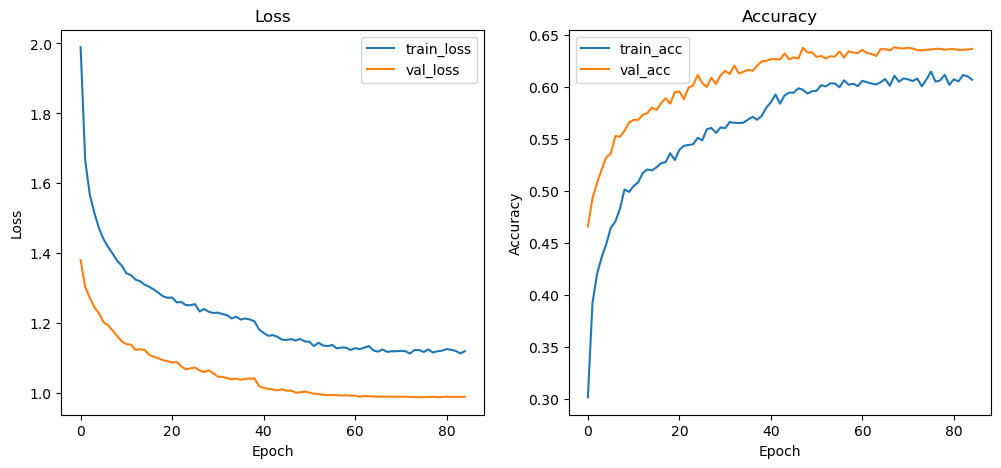

In [23]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [24]:
model = models.load_model(SAVED_MODEL)

In [25]:
# load test data
X_test, y_test = load_keypoints_dataset("../affectnet_keypoints/test")

X_test = X_test.reshape(X_test.shape[0], -1)
# Encode labels using  same LabelEncoder as training
# `le` is label encoder fitted on training labels
y_test_enc = le.transform(y_test) 
# y_test_cat = to_categorical(y_test_enc)  # one-hot

# scaler is the StandardScaler fitted on training data
# scalar.transform() standardizes test features using training mean and std
X_test = scaler.transform(X_test)

print("X_test shape:", X_test.shape)
print("y_test_enc shape:", y_test_enc.shape)

X_test shape: (14480, 1434)
y_test_enc shape: (14480,)


In [26]:
# Predict probabilities
yhat_probs = model.predict(X_test)  # shape (num_samples, 8)

# Convert probabilities to predicted class indices
yhat = np.argmax(yhat_probs, axis=1)

# True class indices
ytrue = y_test_enc

453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [27]:
# def report_test_results_keypoints(X_test, y_test_enc, model, le):
#     print("Evaluating on Test Set...")
    
#     loss, accuracy = model.evaluate(X_test, y_test_enc) 
#     print(f"Test Accuracy: {accuracy*100:.2f}%")

#     print("Generating predictions...")
#     predictions = model.predict(X_test, verbose=0)
#     y_pred_indices = np.argmax(predictions, axis=1)

#     class_labels = le.classes_

#     print("\nClassification Report:\n")
#     print(classification_report(
#         y_test_enc,
#         y_pred_indices,
#         target_names=class_labels
#     ))

#     cm = confusion_matrix(y_test_enc, y_pred_indices)

#     plt.figure(figsize=(10, 8))
#     sns.heatmap(
#         cm,
#         annot=True,
#         fmt='d',
#         cmap='Blues',
#         xticklabels=class_labels,
#         yticklabels=class_labels
#     )
#     plt.xlabel('Predicted Label')
#     plt.ylabel('True Label')
#     plt.title('Confusion Matrix')
#     plt.tight_layout()
#     plt.show()

# report_test_results_keypoints(X_test, y_test_enc, model, le)

453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6288 - loss: 1.2514
Test Accuracy: 62.88%, Test Loss: 1.2514
453/453 ━━━━━━━━━━━━━━━━━━━━ 0s 912us/step
Macro F1: 0.5831

Classification Report:

              precision    recall  f1-score   support

       anger       0.54      0.41      0.46      1705
    contempt       0.58      0.69      0.63      1312
     disgust       0.40      0.46      0.43      1243
        fear       0.53      0.49      0.51      1658
       happy       0.89      0.91      0.90      2703
     neutral       0.73      0.94      0.82      2367
         sad       0.51      0.49      0.50      1576
    surprise       0.50      0.36      0.42      1916

    accuracy                           0.63     14480
   macro avg       0.58      0.59      0.58     14480
weighted avg       0.62      0.63      0.62     14480



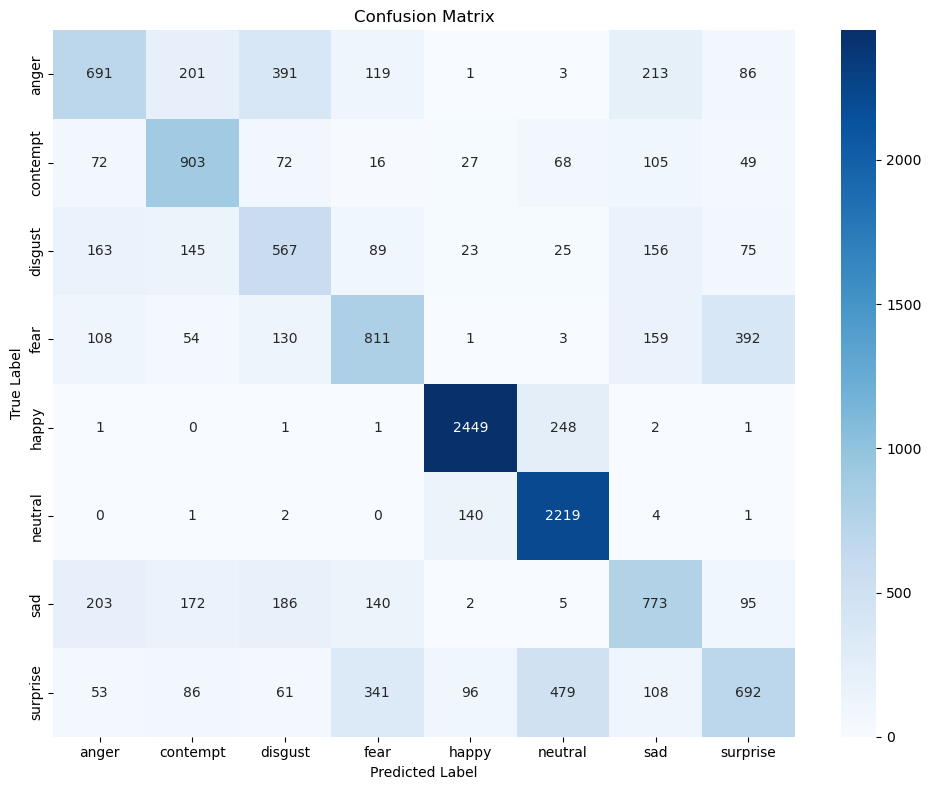

In [28]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test_enc, verbose=1)
print(f"Test Accuracy: {test_acc*100:.2f}%, Test Loss: {test_loss:.4f}")

# Predict probabilities
y_prob = model.predict(X_test, verbose=1)

# Predicted class indices
y_pred = np.argmax(y_prob, axis=1)

# True class indices
y_true = y_test_enc

# Macro F1
macro_f1 = f1_score(y_true, y_pred, average="macro")
print(f"Macro F1: {macro_f1:.4f}")

# Class names from LabelEncoder
class_labels = le.classes_

# Classification report
print("\nClassification Report:\n")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_labels,
        zero_division=0
    )
)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

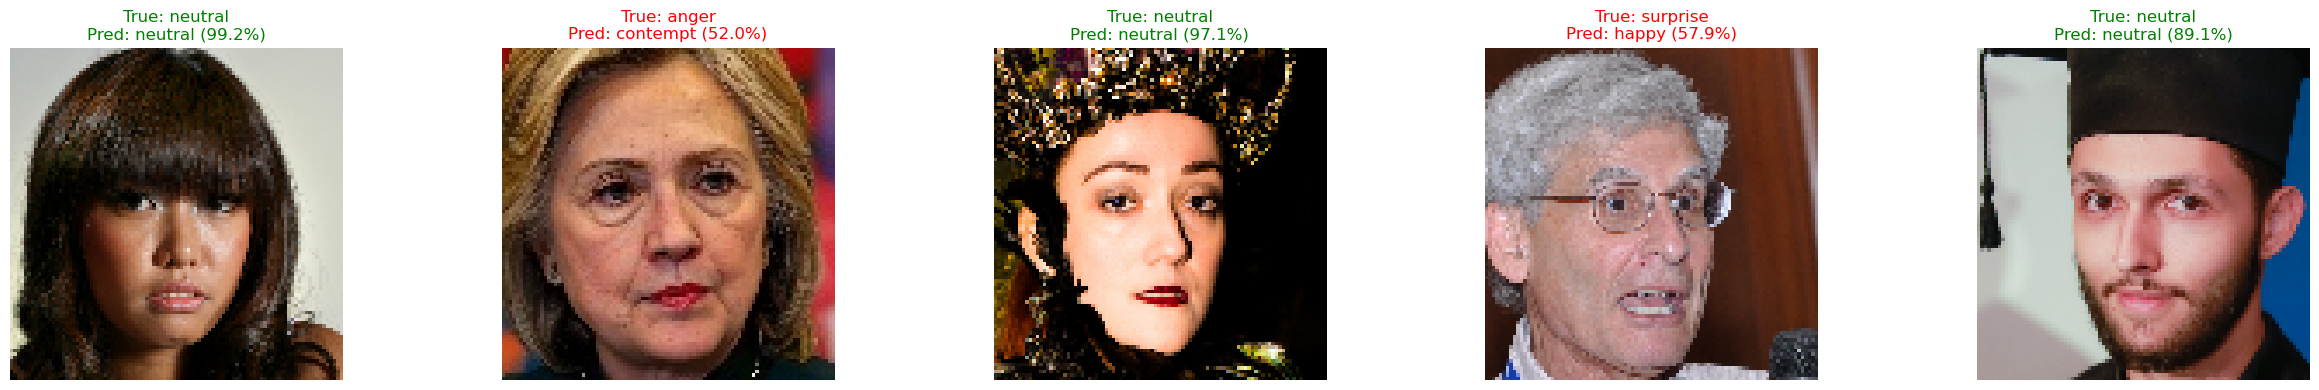

In [31]:
def predict_images_with_keypoints(image_dir, model, scaler, le, n=5):
    images_paths = []

    # collect all images
    for class_name in os.listdir(image_dir):
        class_path = os.path.join(image_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        for img_name in os.listdir(class_path):
            if img_name.startswith("."):
                continue
            images_paths.append((os.path.join(class_path, img_name), class_name))

    # pick random samples
    np.random.seed(RANDOM_SEED)
    samples = np.random.choice(len(images_paths), n, replace=False)

    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))

    for i, idx in enumerate(samples):
        img_path, true_label = images_paths[idx]

        img = cv2.imread(img_path)
        if img is None:
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # --- KEYPOINT EXTRACTION ---
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
        results = detector.detect(mp_image)

        if not results.face_landmarks:
            pred_label = "No face"
            confidence = 0
        else:
            face_landmarks = results.face_landmarks[0]

            keypoints = np.array([[lm.x, lm.y, lm.z] for lm in face_landmarks])
            keypoints = keypoints.reshape(1, -1)

            keypoints = scaler.transform(keypoints)

            pred_prob = model.predict(keypoints, verbose=0)[0]
            pred_idx = np.argmax(pred_prob)
            pred_label = le.classes_[pred_idx]
            confidence = pred_prob[pred_idx] * 100

        axes[i].imshow(img_rgb)
        axes[i].axis("off")

        color = "green" if pred_label == true_label else "red"

        axes[i].set_title(
            f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)",
            color=color
        )

    plt.tight_layout()
    plt.show()

predict_images_with_keypoints(
    "../affectnet_dataset/Test",
    model,
    scaler,
    le,
    n=5
)

In [ ]:
# Divide by 1024**2 to convert bytes to megabytes
size_mb = os.path.getsize(SAVED_MODEL) / (1024**2)

print(f"Model size: {size_mb:.2f} MB")

Model size: 2.57 MB


In [33]:
# Size of MP model (landmarker)
size_mb = os.path.getsize('../face_landmarker_v2_with_blendshapes.task') / (1024**2)

print(f"Model size: {size_mb:.2f} MB")

Model size: 3.58 MB


In [ ]:
def measure_peak_memory(model, x, device="CPU:0"):
    # обнуляєм стати памяті
    tf.config.experimental.reset_memory_stats(device)
    # проганяєм модель на вході x (forward pass)
    y = model(tf.convert_to_tensor(x), training=False)
    # _ - placeholder для результату
    # y.numpy() - примусити TensorFlow виконати обчислення і оновити статистику пам'яті
    _ = y.numpy()
    # отримуємо інформацію про використання пам'яті
    info = tf.config.experimental.get_memory_info(device)
    # переводимо байти в мегабайти
    peak_mb = info["peak"] / (1024**2)
    current_mb = info["current"] / (1024**2)
    return peak_mb, current_mb

In [ ]:
# тестуємо функцію на випадковому вході, який відповідає розміру зображення
input = tf.random.normal((1,1434))
peak_mb, current_mb = measure_peak_memory(
    model,
    input
)

print(f"MLP Peak Memory: {peak_mb:.2f} MB")
print(f"MLP Current Memory: {current_mb:.2f} MB")

MLP Peak Memory: 62.25 MB
MLP Current Memory: 62.25 MB


In [40]:
X_test[:1]

array([[ 1.1008566 , -0.19377567,  0.51433689, ..., -0.4045761 ,
        -0.8546597 , -0.48436737]], shape=(1, 1434))

In [ ]:
x1 = X_test[:1]

_ = model(x1, training=False)

start = time.perf_counter()

for _ in range(100):
    _ = model(x1, training=False)

end = time.perf_counter()

latency_ms = (end - start) / 100 * 1000

print(f"Latency per sample: {latency_ms:.3f} ms")

Latency per sample: 5.939 ms
